# Deep Learning for Time Series

What is a time series (TS), what are aspects that make it interesting, but also challenging to work with TS?

In [1]:
import sys
sys.dont_write_bytecode = True
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
sys.path.insert(1, 'PlotStyles_and_Templates')
from cpsmehelper import get_colors, export_figure
import os
from unittest.mock import patch
cpsme_colors = get_colors()
import matplotlib

plt.style.use(os.path.join(os.getcwd(), 'cps_presentation.mplstyle'))


### Introduction to Time Series

- regularly and irregularly sampled sequences

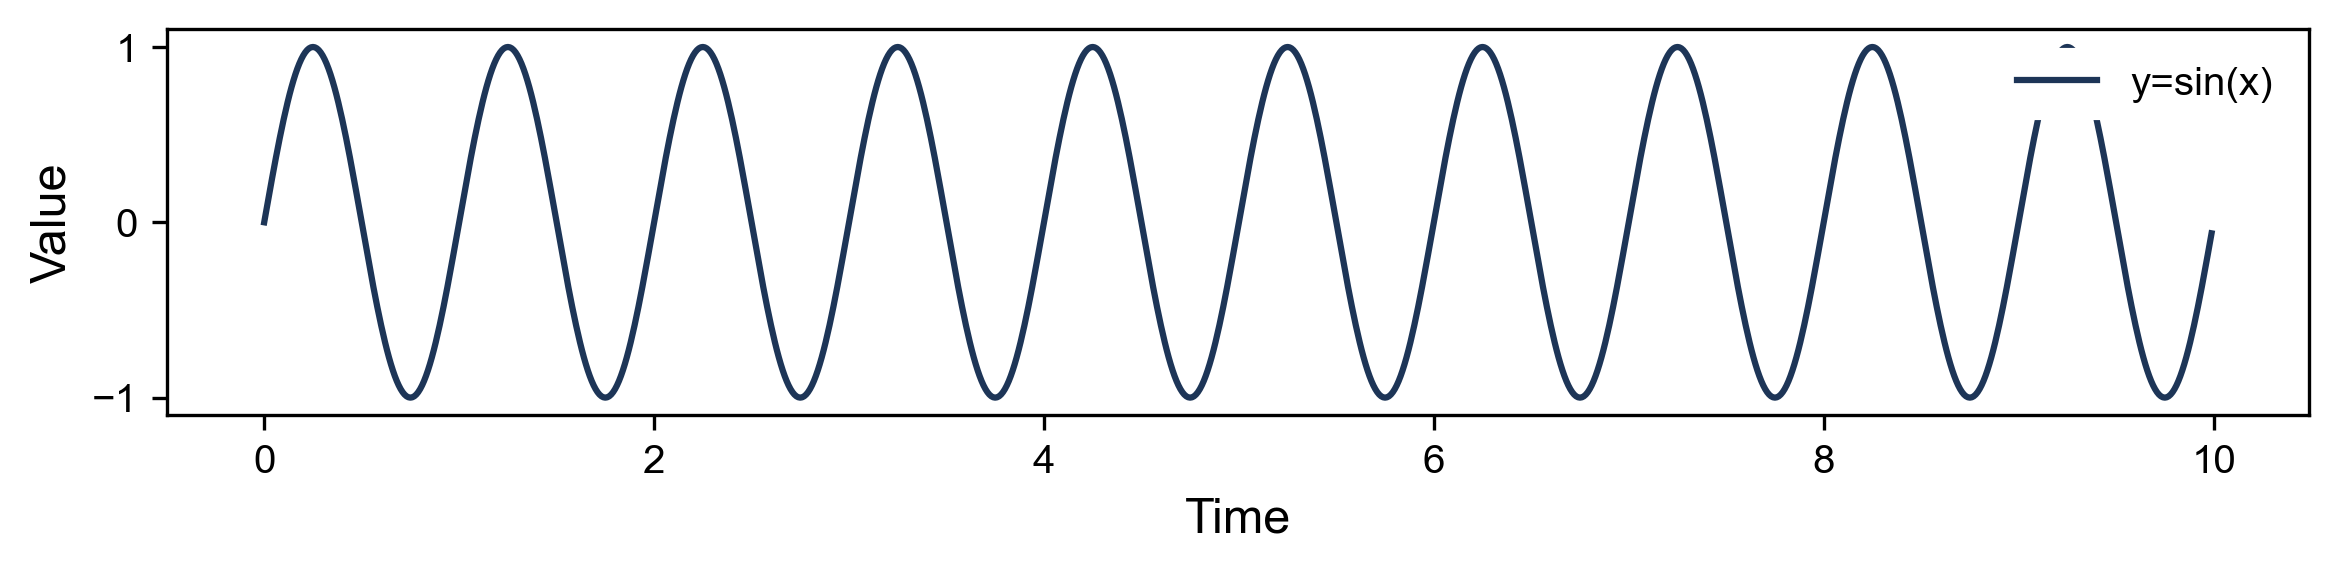

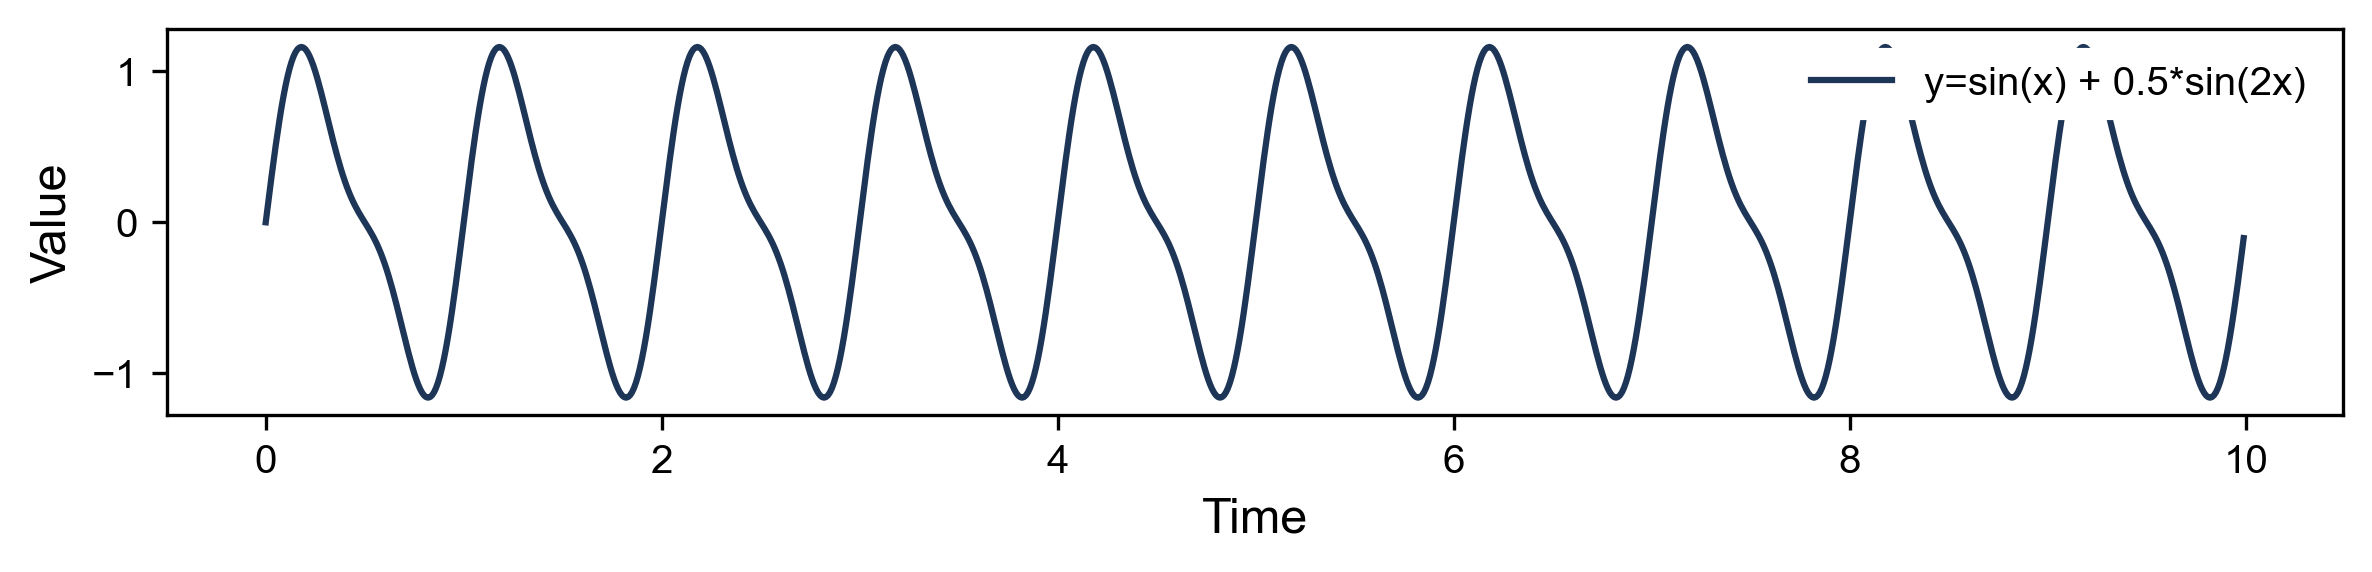

In [3]:
time = np.arange(start=0, stop=10, step=0.01)
plt.figure(figsize=(8, 2))

# purely harmonic time series
plt.plot(time, np.sin(2*np.pi*time), label='y=sin(x)')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

# quasi-periodic time series
plt.figure(figsize=(8, 2))
plt.plot(time, np.sin(2*np.pi*time) + 0.333*np.sin(4*np.pi*time), label='y=sin(x) + 0.5*sin(2x)')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

In [ ]:
# Base signal definition
f = 0.8  # Hz
phi = 0.35

# Regular sampling
t_regular = np.linspace(0, 10, 120, endpoint=True)
y_regular = np.sin(2 * np.pi * f * t_regular + phi)

# Irregular sampling: jitter regular grid and sort to preserve temporal order
rng = np.random.default_rng(42)
t_irregular = np.linspace(0, 10, 120) + rng.normal(loc=0.0, scale=0.04, size=120)
t_irregular = np.clip(np.sort(t_irregular), 0, 10)
y_irregular = np.sin(2 * np.pi * f * t_irregular + phi)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

axes[0].plot(t_regular, y_regular, marker='o', markersize=3, linewidth=1.5, color=cpsme_colors['green'])
axes[0].set_title('Regularly Sampled Time Series')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.25)

axes[1].plot(t_irregular, y_irregular, marker='o', markersize=3, linewidth=1.0, color=cpsme_colors['orange'])
axes[1].set_title('Irregularly Sampled Time Series')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Value')
axes[1].grid(True, alpha=0.25)

fig.tight_layout()
plt.show()